<a href="https://colab.research.google.com/github/d-toups/stock-price-trend-prediction/blob/main/stock_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Trend Prediction with Skewness & Relative Volume

**FSM vs RIG**  
**Author**: Dennis Toups
**Date**: June 2026  

**Objective**:  
Determine whether a stock is in a strong upward trend using only two engineered features:  
- Skewness of normalized closing prices in a rolling window  
- Relative trading volume on the last day  

**Models**: Random Forest vs Gaussian Naive Bayes  
**Target**: Binary classification (price increase > threshold × rolling average)

## Table of Contents
1. [Configuration & Hyperparameters](#config)  
2. [Imports & Setup](#imports)  
3. [Runtime Information](#runtime)  
4. [Data Download & Loading](#data)  
5. [Feature Engineering](#features)  
6. [Model Training & Evaluation](#models)  
7. [Full Analysis](#analysis)  
8. [Results Summary](#summary)  
9. [Visualizations](#plots)  
10. [Conclusions & Next Steps](#conclusions)

## How to Reproduce

### Prerequisites
- Google Colab account
- Two pickle files in the root/content/data/raw directory: `FSM_daily.pkl` and `RIG_daily.pkl`

### Steps to Run:
1. Run all cells in order (Runtime → Run all)
2. The notebook will:
   - Load and process the data
   - Engineer skewness + relative volume features
   - Train Random Forest and Naive Bayes models
   - Save a detailed report: `data/reports/FULL_MODEL_REPORTS.txt`
3. All results, plots, and the combined report file will be generated automatically

### Expected Output
- One combined text report with full classification metrics
- Summary table + 4 visualization plots
- All results saved in `/content/data/reports/`

**Note**: The analysis is fully deterministic (`random_state=42`).

## Configuration & Hyperparameters

In [1]:
STOCKS = ['FSM', 'RIG']
DATA_PATH = '/content/'   # Change if needed

# Analysis parameters
WINDOWS = [14, 60]                    # Rolling period lengths (days)
THRESHOLDS = [1.02, 1.05]             # Last close > threshold × rolling avg

# Features (keep these two for now)
FEATURE_NAMES = ['skewness', 'relative_volume']

# Model settings
TEST_SIZE = 0.20
RANDOM_STATE = 42

# Visualization & Output
PLOT_TREES = True
SHOW_METRICS = True

print("✅ Configuration loaded")
print(f"Stocks: {STOCKS}")
print(f"Windows: {WINDOWS}")
print(f"Thresholds: {THRESHOLDS}")

✅ Configuration loaded
Stocks: ['FSM', 'RIG']
Windows: [14, 60]
Thresholds: [1.02, 1.05]


## Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from joblib import parallel_backend
import os
import yfinance as yf

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
     accuracy_score,
     classification_report,
     confusion_matrix,
     ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


## Runtime Information

In [3]:
import sys
import platform
import sklearn
import multiprocessing
import psutil

print("🔧 Runtime Information")
print("=" * 55)
print(f"Python version     : {sys.version.split()[0]}")
print(f"Platform           : {platform.platform()}")
print(f"Pandas version     : {pd.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Scikit-learn       : {sklearn.__version__}")
print(f"CPU cores available: {multiprocessing.cpu_count()}")
print(f"Available RAM      : {psutil.virtual_memory().total / (1024**3):.1f} GB")
print(f"Current working dir: {os.getcwd()}")

print("\n✅ Runtime ready for reproducible analysis")

🔧 Runtime Information
Python version     : 3.12.13
Platform           : Linux-6.6.122+-x86_64-with-glibc2.35
Pandas version     : 2.2.2
NumPy version      : 2.0.2
Scikit-learn       : 1.6.1
CPU cores available: 2
Available RAM      : 12.7 GB
Current working dir: /content

✅ Runtime ready for reproducible analysis


## Data Download & Loading

In [4]:
# Create data directory
os.makedirs('/content/data', exist_ok=True)

# Define file paths
fsm_path = '/content/data/FSM_daily.pkl'
rig_path = '/content/data/RIG_daily.pkl'

# ====================== DOWNLOAD IF MISSING ======================
print("📥 Checking for data files...")

if not os.path.exists(fsm_path) or not os.path.exists(rig_path):
    print("   → Pickle files not found. Downloading fresh data from Yahoo Finance...\n")

    # Install yfinance if not present
    try:
        import yfinance as yf
    except ImportError:
        print("   Installing yfinance...")
        !pip install yfinance -q
        import yfinance as yf

    # Download data
    for ticker, filepath in zip(["FSM", "RIG"], [fsm_path, rig_path]):
        print(f"   Downloading {ticker}...")
        df = yf.download(
            ticker,
            start="2020-11-25",
            end="2025-11-25",
            auto_adjust=True,
            progress=False
        )
        df.to_pickle(filepath)
        print(f"   ✅ {ticker} saved ({len(df)} rows)")

else:
    print("   ✅ Pickle files already exist. Loading from disk.")

# ====================== LOAD DATA ======================
fsm = pd.read_pickle(fsm_path)
rig = pd.read_pickle(rig_path)

print("\n✅ Data successfully loaded!")
print(f"FSM shape: {fsm.shape} | Date range: {fsm.index[0].date()} to {fsm.index[-1].date()}")
print(f"RIG shape: {rig.shape} | Date range: {rig.index[0].date()} to {rig.index[-1].date()}")

📥 Checking for data files...
   ✅ Pickle files already exist. Loading from disk.

✅ Data successfully loaded!
FSM shape: (1255, 5) | Date range: 2020-11-25 to 2025-11-24
RIG shape: (1255, 5) | Date range: 2020-11-25 to 2025-11-24


## Feature Engineering

In [5]:
def engineer_features(raw: pd.DataFrame, window: int, threshold: float):
    """
    Engineer skewness + relative volume features with binary target.
    """
    # Basic validation
    if raw.isna().any().any():
        raise ValueError("Missing or invalid data detected")

    data = []

    for i in range(window - 1, len(raw)):
        block = raw.iloc[i - window + 1 : i + 1]

        # Force clean scalars
        avg_price = float(block['Close'].mean().item())
        last_price = float(block['Close'].iloc[-1].item())

        # Normalized prices → skewness
        norm_prices = block['Close'] / avg_price
        skewness = float(norm_prices.skew().item())

        # Relative volume
        avg_vol = float(block['Volume'].mean())
        last_vol = float(block['Volume'].iloc[-1])
        rel_volume = last_vol / avg_vol if avg_vol != 0 else 0.0

        # Target
        trend = 1 if last_price > (threshold * avg_price) else 0

        data.append([skewness, rel_volume, trend])

    df_features = pd.DataFrame(data, columns=['skewness', 'relative_volume',
                                              'target'])
    return df_features

## Model Training and Evaluation

In [6]:
def evaluate_models(X, y, stock_name, window, threshold, verbose=True):
    """
    Train Random Forest + Naive Bayes.
    Set verbose=False to suppress detailed output during full runs.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    # === Random Forest ===
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    # === Naive Bayes ===
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred_nb = nb.predict(X_test)

    # === Only print when verbose=True ===
    if verbose:
        print(f"\n=== {stock_name} | Window={window} | Threshold={threshold} ===")
        print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
        print(classification_report(y_test, y_pred_rf,
                                    target_names=["Not Trending", "Trending"],
                                    zero_division=0))

        print(f"Naive Bayes Accuracy:   {accuracy_score(y_test, y_pred_nb):.4f}")
        print(classification_report(y_test, y_pred_nb,
                                    target_names=["Not Trending", "Trending"],
                                    zero_division=0))

    return rf, nb, y_test, y_pred_rf, y_pred_nb

##

## Full Analysis

In [7]:
summary = []

print("🚀 Starting full analysis across all combinations...\n")

for symbol, df_raw in zip(['FSM', 'RIG'], [fsm, rig]):
    for window in WINDOWS:
        for thresh in THRESHOLDS:
            features = engineer_features(df_raw, window, thresh)
            X = features[['skewness', 'relative_volume']].values
            y = features['target'].values

            # Run with verbose=False to keep output clean
            rf_model, nb_model, y_test, y_pred_rf, y_pred_nb = evaluate_models(
                X, y, symbol, window, thresh, verbose=False
            )

            # Store results
            summary.append({
                'Stock': symbol,
                'Window': window,
                'Threshold': thresh,
                'Threshold_%': f"{int((thresh-1)*100)}%",
                'Model': 'Random Forest',
                'Accuracy': accuracy_score(y_test, y_pred_rf)
            })
            summary.append({
                'Stock': symbol,
                'Window': window,
                'Threshold': thresh,
                'Threshold_%': f"{int((thresh-1)*100)}%",
                'Model': 'Naive Bayes',
                'Accuracy': accuracy_score(y_test, y_pred_nb)
            })

print("✅ Full analysis completed!\n")

🚀 Starting full analysis across all combinations...

✅ Full analysis completed!



## Results Summary and Report File

In [8]:
report_dir = 'reports'
combined_report_path = os.path.join(report_dir, "FULL_MODEL_REPORTS.txt")

summary = []

print("🚀 Running full evaluation...\n")

with open(combined_report_path, 'w') as f:
    f.write("STOCK TREND PREDICTION - FULL MODEL REPORTS\n")
    f.write("="*80 + "\n\n")

    for symbol, df_raw in zip(['FSM', 'RIG'], [fsm, rig]):
        for window in WINDOWS:
            for thresh in THRESHOLDS:
                features = engineer_features(df_raw, window, thresh)
                X = features[['skewness', 'relative_volume']].values
                y = features['target'].values

                # Run models silently (no console spam)
                rf_model, nb_model, y_test, y_pred_rf, y_pred_nb = evaluate_models(
                    X, y, symbol, window, thresh, verbose=False
                )

                # === Write detailed reports to file only ===
                f.write(f"STOCK: {symbol} | WINDOW: {window} days | "
                        f"THRESHOLD: {thresh} ({int((thresh-1)*100)}%)\n")
                f.write("-"*70 + "\n")
                f.write(f"Samples: {len(y)}\n\n")

                f.write("RANDOM FOREST\n")
                f.write(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
                f.write(classification_report(y_test, y_pred_rf,
                                            target_names=["Not Trending", "Trending"],
                                            zero_division=0))

                f.write("\nNAIVE BAYES\n")
                f.write(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
                f.write(classification_report(y_test, y_pred_nb,
                                            target_names=["Not Trending", "Trending"],
                                            zero_division=0))
                f.write("\n" + "="*80 + "\n\n")

                # Store summary data
                summary.append({
                    'Stock': symbol,
                    'Window': window,
                    'Threshold': thresh,
                    'Threshold_%': f"{int((thresh-1)*100)}%",
                    'Model': 'Random Forest',
                    'Accuracy': accuracy_score(y_test, y_pred_rf)
                })
                summary.append({
                    'Stock': symbol,
                    'Window': window,
                    'Threshold': thresh,
                    'Threshold_%': f"{int((thresh-1)*100)}%",
                    'Model': 'Naive Bayes',
                    'Accuracy': accuracy_score(y_test, y_pred_nb)
                })

print(f"✅ Detailed reports saved to: {combined_report_path}")
print("   (You can download it from the file browser)\n")

# ====================== SUMMARY TABLE (in notebook) ======================
summary_df = pd.DataFrame(summary)

# Nice ordering
summary_df['order'] = summary_df.apply(
    lambda x: (x['Threshold'], x['Window'],
               0 if x['Stock']=='FSM' else 1,
               0 if x['Model']=='Random Forest' else 1), axis=1
)
summary_df = summary_df.sort_values('order').drop(columns='order')

print("=== SUMMARY TABLE ===")
display_cols = ['Stock', 'Window', 'Threshold_%', 'Model', 'Accuracy']
display(summary_df[display_cols].round(4).style.set_caption("Model Performance Summary"))

🚀 Running full evaluation...

✅ Detailed reports saved to: reports/FULL_MODEL_REPORTS.txt
   (You can download it from the file browser)

=== SUMMARY TABLE ===


,Stock,Window,Threshold_%,Model,Accuracy
0,FSM,14,2%,Random Forest,0.618500
1,FSM,14,2%,Naive Bayes,0.598400
8,RIG,14,2%,Random Forest,0.598400
9,RIG,14,2%,Naive Bayes,0.602400
4,FSM,60,2%,Random Forest,0.645800
5,FSM,60,2%,Naive Bayes,0.579200
12,RIG,60,2%,Random Forest,0.666700
13,RIG,60,2%,Naive Bayes,0.670800
2,FSM,14,5%,Random Forest,0.751000
3,FSM,14,5%,Naive Bayes,0.743000


## Visualizations

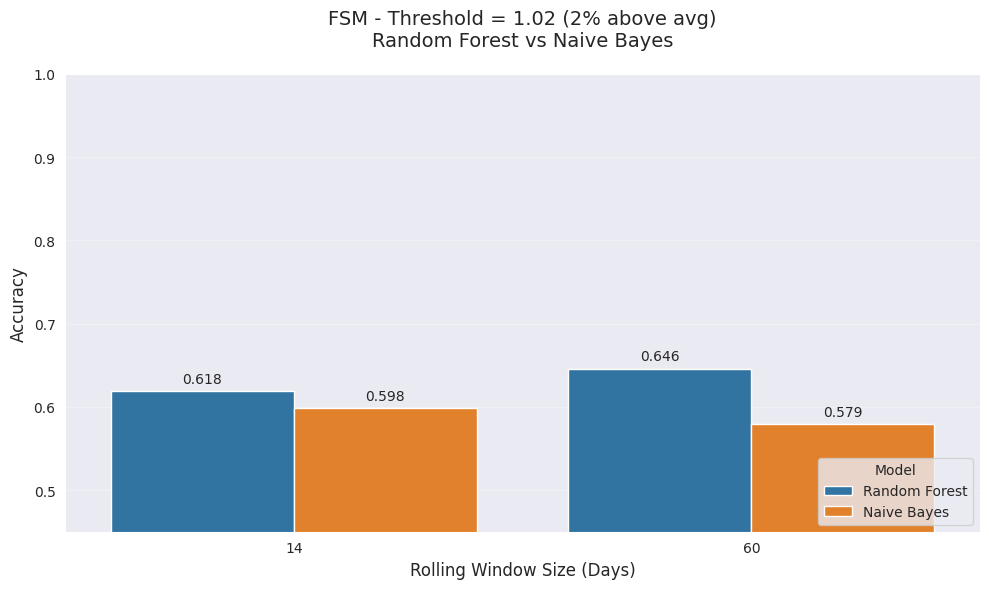

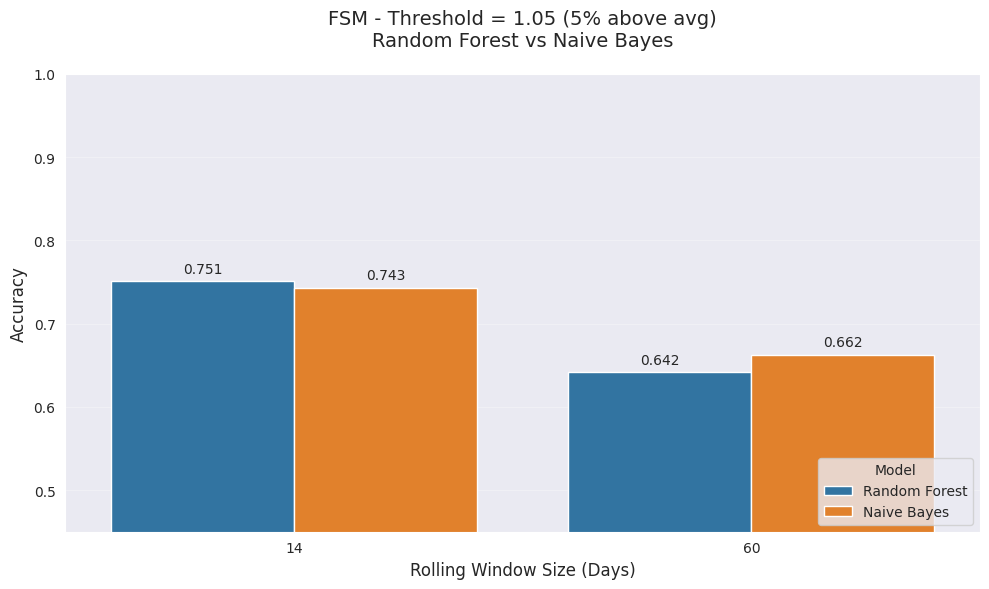

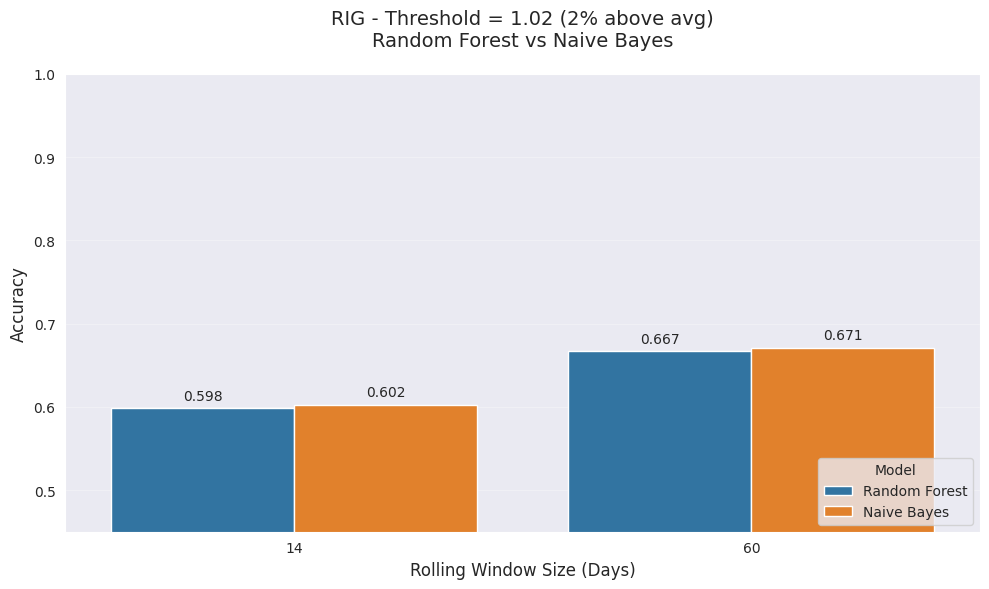

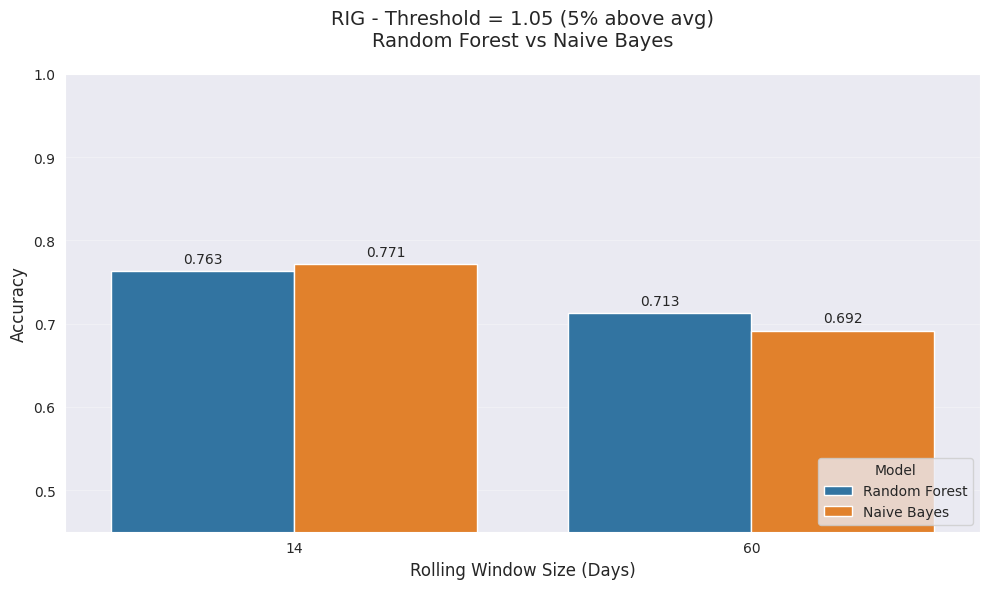

In [9]:
if 'summary_df' not in globals():
    print("⚠️ Please run the analysis cell first!")
else:
    for stock in ['FSM', 'RIG']:
        for thresh in sorted(THRESHOLDS):
            plot_data = summary_df[
                (summary_df['Stock'] == stock) &
                (summary_df['Threshold'] == thresh)
            ].copy()

            plt.figure(figsize=(10, 6))

            sns.barplot(
                data=plot_data,
                x='Window',
                y='Accuracy',
                hue='Model',
                palette=['#1f77b4', '#ff7f0e'],
                dodge=True,
                errorbar=None
            )

            plt.title(f'{stock} - Threshold = {thresh} ({int((thresh-1)*100)}% above avg)\n'
                      f'Random Forest vs Naive Bayes', fontsize=14, pad=20)

            plt.ylabel('Accuracy', fontsize=12)
            plt.xlabel('Rolling Window Size (Days)', fontsize=12)
            plt.ylim(0.45, 1.0)
            plt.legend(title='Model', loc='lower right')

            # Value labels
            ax = plt.gca()
            for container in ax.containers:
                ax.bar_label(container, fmt='%.3f', padding=4)

            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

# Conclusions & Next Steps

## Key Findings

After running multiple iterations, the analysis shows:

- The **5% threshold (1.05)** consistently produced **higher accuracy** than the 2% threshold across both stocks and models.
- **Window Size Effect**:
  - At the 5% threshold, the **14-day window** generally performed better.
  - At the 2% threshold, results were mixed (FSM was similar across windows, RIG favored 60 days).
- **Model Performance**:  
  **Random Forest and Gaussian Naive Bayes performed very similarly overall.**  
  Each model outperformed the other in exactly 4 out of the 8 total scenarios. This suggests that with only two features (skewness + relative volume), the added complexity of Random Forest does not provide a clear advantage over the simpler Naive Bayes in this specific case.

### Overall Takeaway
Skewness and relative volume contain **real predictive signal** for upward stock trends, especially when targeting stronger moves (5% above rolling average). However, with this limited feature set, a simple probabilistic model (Naive Bayes) is competitive with a more sophisticated ensemble (Random Forest).

This highlights an important lesson: **more complex models are not always better** — especially when the underlying signal is relatively weak or the feature space is small.

---

## Limitations
- Only two engineered features used
- Standard random train/test split (no time-series aware validation)
- No trading costs, slippage, or risk management considered
- Limited to two stocks over a specific time period

---

## Future Work & Improvements

1. **Feature Expansion** — Add RSI, ATR, momentum, volume trends, moving average ratios, etc.
2. **Better Validation** — Implement walk-forward optimization or purged time-series cross-validation
3. **Advanced Models** — Test XGBoost, LightGBM, and LSTM/Transformers
4. **Trading Strategy** — Build a full backtested system with position sizing and risk rules
5. **Broader Testing** — Include more stocks and different market regimes

---

**Final Note**:  
This project successfully demonstrates end-to-end analysis — from data handling and feature engineering to model comparison and clear reporting. The competitive performance between Random Forest and Naive Bayes with minimal features makes for an interesting case study in model simplicity vs complexity.

The notebook provides a clean, reproducible foundation for further experimentation.